In [2]:
import sys
sys.path.insert(0, "/home/jovyan/d-shlenskii/repos/skyloop/ott/src")

In [3]:
# import shutup
# shutup.please()

import os
os.environ['CUDA_VISIBLE_DEVICES']='2'

import warnings
warnings.filterwarnings('ignore')

# import rootutils
# ROOT = rootutils.setup_root(indicator='README.md', search_from=os.path.abspath(''), pythonpath=True, cwd=True)

import jax
import jax.numpy as jnp
import optax
from jaxtyping import ArrayLike, Float
import numpy as np
GLOBAL_KEY = jax.random.key(42)

import seaborn as sns
import matplotlib.pyplot as plt
# plt.style.use(['science', 'notebook'])

# Lagrangian Potentials

from ott2.neural.methods.lagrangian.lagrangian_potentials import *

%load_ext autoreload
%autoreload 2


In [4]:
## Utils

def draw_trajs(trajs: Float[ArrayLike, 'timestep point dim=2'], ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    colors = sns.color_palette("pastel", trajs.shape[1])
    
    for point in range(trajs.shape[1]):
        for t in range(1, trajs.shape[0]):
            ax.plot([trajs[t-1, point, 0], trajs[t, point, 0]],
                    [trajs[t-1, point, 1], trajs[t, point, 1]],
                    color=colors[point], linestyle="-", linewidth=1, marker='o', alpha=0.6, markersize=1)
    return ax

In [5]:
from torch.utils.data import Dataset, DataLoader

class InfiniteLoaderWrapper:
    def __init__(self, loader: DataLoader):
        self.loader = loader
        self.loader_it = iter(loader)
    
    def __iter__(self):
        self.loader_it = iter(self.loader)
        return self

    def __next__(self):
        try:
            batch = next(self.loader_it)
        except StopIteration:
            self.loader_it = iter(self.loader)
            batch = next(self.loader_it)
        return batch

class OTLoader:
    def __init__(
        self,
        src_ds: Dataset,
        trg_ds: Dataset,
        image_flag: bool = False,
        **torch_dataloader_kwargs,
    ):
        def collate_fn(batch: tuple[np.ndarray]):
            return np.stack(batch)

        self.src_loader = InfiniteLoaderWrapper(DataLoader(src_ds, collate_fn=collate_fn, **torch_dataloader_kwargs))
        self.trg_loader = InfiniteLoaderWrapper(DataLoader(trg_ds, collate_fn=collate_fn, **torch_dataloader_kwargs))
        self.image_flag = image_flag

    def __iter__(self):
        self.src_loader = iter(self.src_loader)
        self.trg_loader = iter(self.trg_loader)
        return self

    def __next__(self):
        src_batch = jnp.asarray(next(self.src_loader))
        tgt_batch = jnp.asarray(next(self.trg_loader))
        if self.image_flag:
            b_size = src.shape[0]
            src_batch = src_batch.reshape(b_size, -1)
            tgt_batch = tgt_batch.reshape(b_size, -1)
        output = {
            "src_lin": jnp.asarray(next(self.src_loader)),
            "tgt_lin": jnp.asarray(next(self.trg_loader)),
        }

# Neural

In [6]:
import flax.linen as nn

In [7]:
class MLP(nn.Module):
    hidden_layers: list
    
    @nn.compact
    def __call__(self, t, x, _):
        x = jnp.concatenate([x, t], -1)
        for i, dim in enumerate(self.hidden_layers):
            x = nn.Dense(dim)(x)
            if i != len(self.hidden_layers) - 1:
                x = nn.leaky_relu(x)
        return x

In [51]:
from ott2.neural.networks.resnet_d import ResNet_D


class ResNetDwTime(nn.Module):
    size: int = 64 
    nlayers: int = 4
    nc: int = 3
    nfilter: int = 64
    nfilter_max: int = 512

    @nn.compact
    def __call__(self, t, x, train=True):
        b_size = t.shape[0]

        x = x.reshape(-1, self.nc, self.size, self.size)

        t_emb = nn.Dense(self.size**2)(t[:, None]) # [b, size**2]
        t_emb = t_emb.reshape(b, 1, self.size, self.size)

        x_with_t = jnp.concatenate([x, t_emb], axis=1)
        return ResNet_D(
            size=self.size,
            nlayers=self.nlayers,
            nc=self.nc+1,
            nfilter=self.nfilter,
            nfilter_max=self.nfilter_max,
        )(x_with_t)

# Neural Optimal Control

In [55]:
import numpy as np

from ott2.neural.methods.nocc import NeuralOC
from ott2.neural.methods.flows.dynamics import LagrangianFlow
from IPython.display import clear_output

from flax.struct import PyTreeNode

In [59]:
class LagrangianPotentialFree(PyTreeNode):
    @abstractmethod
    def __call__(self, x):
        return 0.

## Toy Example

In [8]:
ds_size = 10_000
ds_dim = 2
sigma = 0.1

src_mu = np.asarray([-1., -1.])
trg_mu = np.asarray([1., 1.])

ot_loader = OTLoader(
    src_ds=np.random.randn(ds_size, ds_dim) * sigma + src_mu,
    trg_ds=np.random.randn(ds_size, ds_dim) * sigma + trg_mu,
    shuffle=True,
    batch_size=512,
)
ot_loader = iter(ot_loader)

In [10]:
potential_data_loader = iter(ot_loader)
potential = LagrangianPotentialFree()

def callback(step, training_logs, transport):
    clear_output()
    pi0 = next(potential_data_loader)['src_lin']
    pi1 = next(potential_data_loader)['tgt_lin']

    cost, trajs = transport(pi0)

    fig, ax = plt.subplots()
    ax.scatter(pi0[:,0], pi0[:, 1], c='red', alpha=1, s=4)
    ax.scatter(pi1[:,0], pi1[:, 1], c='black', alpha=0.5, s=10)
    ax.scatter(trajs[-1].x[:, 0], trajs[-1].x[:, 1], c='green', s=10)
    ax.set_xlim((-1.5, 1.5))
    ax.set_ylim((-1.5, 1.5))
    draw_trajs(trajs=jnp.stack([traj.x for traj in trajs])[:, :100], ax=ax)
    plt.show()
     
net = MLP(hidden_layers=[256, 256, 256, 1])
num_iterations = 10_001
lr_schedule = optax.cosine_decay_schedule(
    init_value=2e-5, decay_steps=num_iterations, alpha=1e-2
)
noc = NeuralOC(input_dim=2, 
               value_model=net, 
               optimizer=optax.adam(learning_rate=lr_schedule), 
               control_steps=30,
               reg_weight=0.001,
               control_weight=0.1, 
               acc_weight=0.5,
               # potential_weight=-500, 
               potential_weight=0., 
               flow=LagrangianFlow(sigma=0.1, potential=potential), 
               key=GLOBAL_KEY)

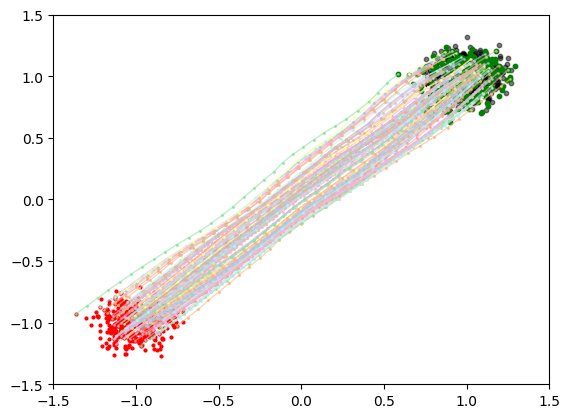

100%|█████████▉| 10000/10001 [01:23<00:00, 119.60it/s, pot_loss=-0.06000576, cost_loss=0.02626495]


In [11]:
logs = noc(potential_data_loader, n_iters=num_iterations, rng=GLOBAL_KEY, callback=callback)

## Images example

In [57]:
ds_size, nc, dim = 2_000, 3, 64

ot_loader = OTLoader(
    src_ds=np.random.randn(ds_size, nc, dim, dim),
    trg_ds=np.random.randn(ds_size, nc, dim, dim),
    shuffle=True,
    batch_size=2,
)
ot_loader = iter(ot_loader)

In [60]:
potential_data_loader = iter(ot_loader)
potential = LagrangianPotentialFree()
     
net = ResNetDwTime(size=dim, nc=nc)
num_iterations = 10_001
lr_schedule = optax.cosine_decay_schedule(
    init_value=2e-5, decay_steps=num_iterations, alpha=1e-2
)
noc = NeuralOC(input_dim=2, 
               value_model=net, 
               optimizer=optax.adam(learning_rate=lr_schedule), 
               control_steps=30,
               reg_weight=0.001,
               control_weight=0.1, 
               acc_weight=0.5,
               # potential_weight=-500, 
               potential_weight=0., 
               flow=LagrangianFlow(sigma=0.1, potential=potential), 
               key=GLOBAL_KEY)

TypeError: cannot reshape array of shape (1, 2) (size 2) into shape (-1, 3, 64, 64) because the product of specified axis sizes (12288) does not evenly divide 2